<a id="top"></a>
<div class="list-group" id="list-tab" role="tablist">
<h1 class="list-group-item list-group-item-action active" data-toggle="list" style='background:#005097; border:0' role="tab" aria-controls="home"><center>APRENDIZADO DE MÁQUINA (CIC1205/GCC1932) - Trabalho 2</center></h1>

- Nome completo: Erich Johann
- [Link para vídeo](https://youtu.be/ZiMVbd4shMc)

# 1 Engenharia de Features

In [44]:
import pandas as pd
diamonds_original = pd.read_csv("https://raw.githubusercontent.com/AILAB-CEFET-RJ/cic1205/main/data/diamonds.csv")
diamonds = diamonds_original.copy()

In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

num_cols = ['price', 'carat', 'depth', 'table', 'x', 'y', 'z', 'volume', 'quality', 'density', 'cut_order', 'color_order', 'clarity_order']
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

cut_map = {k: i for i, k in enumerate(cut_order)}
color_map = {k: i for i, k in enumerate(color_order)}
clarity_map = {k: i for i, k in enumerate(clarity_order)}

diamonds['cut_order'] = diamonds['cut'].map(cut_map)
diamonds['color_order'] = diamonds['color'].map(color_map)
diamonds['clarity_order'] = diamonds['clarity'].map(clarity_map)

diamonds['quality'] = diamonds['cut_order'] + diamonds['color_order'] + diamonds['clarity_order']
diamonds['volume'] = diamonds['x'] * diamonds['y'] * diamonds['z']
diamonds['density'] = diamonds['carat'] / diamonds['volume']

preprocessor = ColumnTransformer(transformers=[
    ('std', StandardScaler(), num_cols[1:])
])

Mapeamos features categóricas para numérica usando codificação ordinal tendo em vista que há uma ordem de grandeza entre cada valor
Criamos as variáveis quality, volume density, com objetivo de auxiliar o modelo a relacionar a relação entre algumas de suas features.

quality - soma das características cut, color, clarity.

volume - multiplicação x, y, z.

density - divisão peso volume.

A normalização segue a mesma do trabalho passado onde foi feito a exploração dos dados.

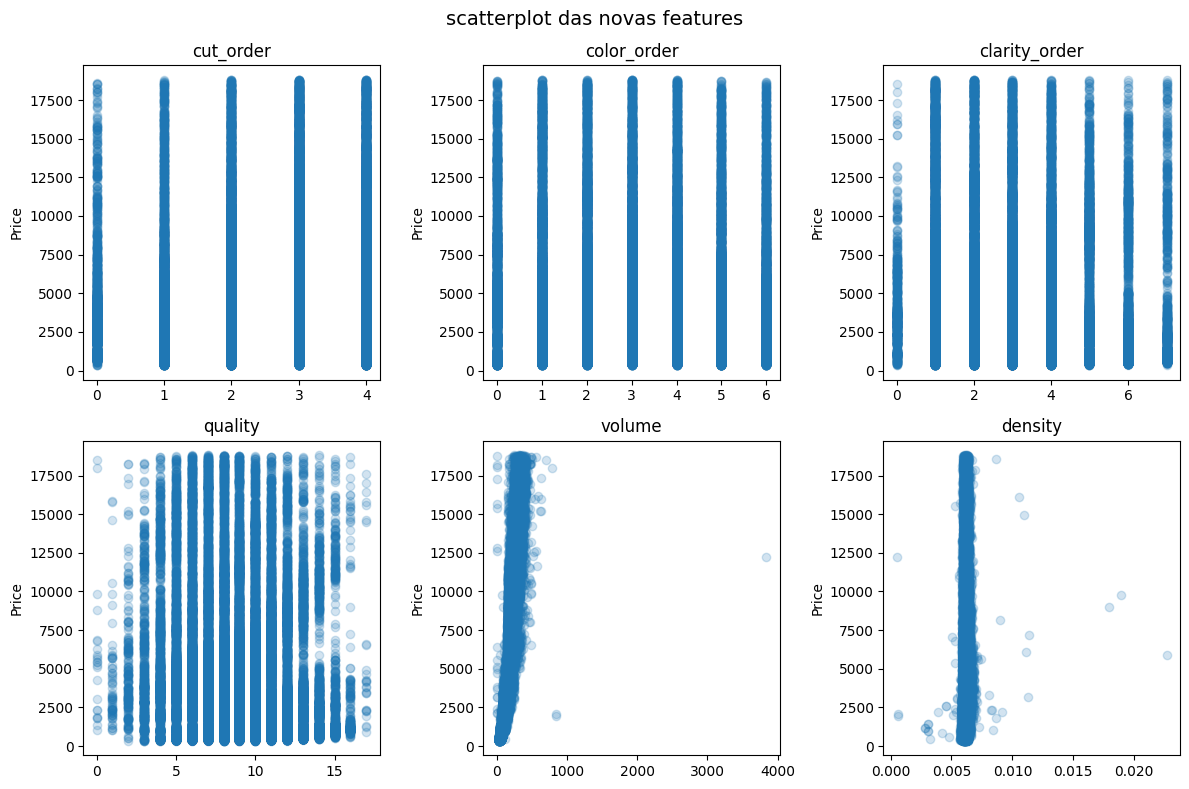

In [48]:
import matplotlib.pyplot as plt

new_cols = ['cut_order', 'color_order', 'clarity_order', 'quality', 'volume', 'density']

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(new_cols):
    axes[i].scatter(diamonds[col], diamonds['price'], alpha=0.2)
    axes[i].set_title(col)
    axes[i].set_ylabel('Price')

# Esconde o último subplot se houver espaço sobrando
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('scatterplot das novas features', fontsize=14)
plt.tight_layout()
plt.show()

Analisando os gráficos das novas features pelo preço percebemos que as variáveis relacionadas a qualidade tem uma distribuição bem abrangente e não apresentam relação clara. Somente a claridade que sua pior categoria apresenta valor ínfimos de diamantes caros. Talvez impurezas que reduzem sua classificação também impactam carat que tem correlação muito positiva com o preço.

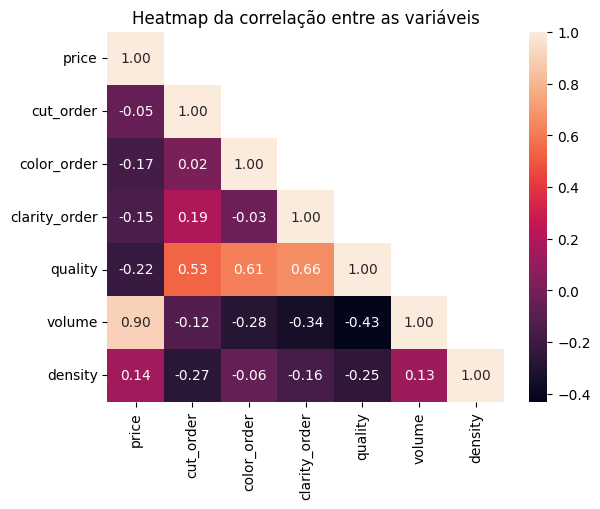

In [49]:
import seaborn as sns
import numpy as np

corr_matrix = diamonds[['price'] + new_cols].corr()

# Criar máscara para o triângulo superior
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(corr_matrix, annot=True, fmt='.2f', mask=mask)
plt.title('Heatmap da correlação entre as variáveis')
plt.show()

As variáveis categoricas obtiveram correlação negativa, porém volume recebeu uma correção altamente positiva e a densidade pouco positiva. Provavelmente um diamante que tenha a melhor qualidade seja muito raramente grande e pesado, ao mesmo tempo um diamante massivo que é muito raro como tem pouquissimos exemplos eles não tiveram a sorte de também terem as melhores características relacionadas a qualidade.

In [51]:
min_volume = diamonds.loc[diamonds['volume'] > 0, 'volume'].min()
diamonds['volume'] = diamonds['volume'].replace(0, min_volume / 100)
diamonds['density'] = diamonds['carat'] / diamonds['volume']

Alguns diamantes tinham x, y ou z = 0 o que fazia a volume zerar e a densidade explodir para infinito, para resolver isso substituimos volume = 0 por uma fração do menor volume encontrado.

In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

x = diamonds.drop(columns=['price'])
y = diamonds['price']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

pipe = Pipeline([
    ('pre', preprocessor),
    ('model', LinearRegression())
])

pipe.fit(x_train, y_train)
y_pred = pipe.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.4f}")

MSE: 1494829.00
R²: 0.9060


In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

x = diamonds_original.drop(columns=['price', 'cut', 'color', 'clarity'])
y = diamonds_original['price']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.4f}")

MSE: 2242178.90
R²: 0.8590


In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

cat_cols = ['cut', 'color', 'clarity']
num_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']

x = diamonds.drop(columns=['price', 'volume', 'density', 'quality'])
y = diamonds['price']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

preprocessor = ColumnTransformer(transformers=[
    ('std', StandardScaler(), num_cols),
    ("ord", OrdinalEncoder(categories=[cut_order, color_order, clarity_order]), cat_cols)
])

pipe = Pipeline([
    ('pre', preprocessor),
    ('model', LinearRegression())
])

pipe.fit(x_train, y_train)
y_pred = pipe.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.4f}")

MSE: 1499636.69
R²: 0.9057


Avaliando o treinamento dos 3 modelos os quais:


1.   Usou variáveis criadas.
2.   Não usou nenhuma variável criada nem normalização de dados.
3.   Usou somente normalização

O primeiro foi o que melhor performou, seguido de perto pelo terceiro modelo e em último com pior desenpenho temos o segundo modelo.

Assim podemos concluir que as features ajudaram positivamente o modelo a melhorar as suas predições.



# 2 Classificação Ordinal Multiclasse

In [55]:
import pickle
import numpy as np

f = open("A652.pickle", 'rb')

(X_train, y_train, X_val, y_val, X_test, y_test) = pickle.load(f)

X_train_full = np.concatenate([X_train, X_val], axis=0)
y_train_full = np.concatenate([y_train, y_val], axis=0)
X_train_full = np.concatenate([X_train_full, X_test], axis=0)
y_train_full = np.concatenate([y_train_full, y_test], axis=0)

idx = int(len(X_train_full) * 0.8)
X_train, y_train = X_train_full[:idx], y_train_full[:idx]
X_test, y_test = X_train_full[idx:], y_train_full[idx:]

def categorize(y):
  if y == 0:
    return 0
  if y <= 5:
    return 1
  if y <= 25:
    return 2
  if y <= 50:
    return 3
  if y > 50:
    return 4

y_train_mclass = np.array([categorize(y) for y in y_train])
y_test_mclass = np.array([categorize(y) for y in y_test])

Import dos dados e separação por classes seguindo as condições dadas:

* 0 → NONE
* (0,5] → WEAK
* (5,25] → MODERATE
* (25,50] → STRONG
* (50,∞) → EXTREME

In [56]:
from sklearn.ensemble import GradientBoostingClassifier

models = []

for i in range(4):
  y_bin = np.array([1 if y > i else 0 for y in y_train_mclass])
  models.append(GradientBoostingClassifier())
  models[i].fit(X_train, y_bin)

Treinamento dos modelos

In [57]:
import numpy as np

results = []

for i in range(4):
  y_pred = models[i].predict_proba(X_test)[:, 1]
  results.append(y_pred)

prob = np.zeros([len(y_test), 5])
prob[:,0] = 1 - results[0]
prob[:,1] = results[0] - results[1]
prob[:,2] = results[1] - results[2]
prob[:,3] = results[2] - results[3]
prob[:,4] = results[3]

y_pred = np.argmax(prob, axis=1)

Avaliação no conjunto de teste pegando a previsão do modelo com maior probabilidae como a classe

In [58]:
gbc = GradientBoostingClassifier()
gbc.fit(X_train, y_train_mclass)

y_pred_baseline = gbc.predict(X_test)

Treinamento de modelo base convencional para comparação

=== Multiclass Ordinal Classifier ===
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      4073
           1       0.71      0.40      0.51       322
           2       0.08      0.05      0.06        21
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         1

    accuracy                           0.94      4420
   macro avg       0.35      0.29      0.31      4420
weighted avg       0.93      0.94      0.93      4420



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


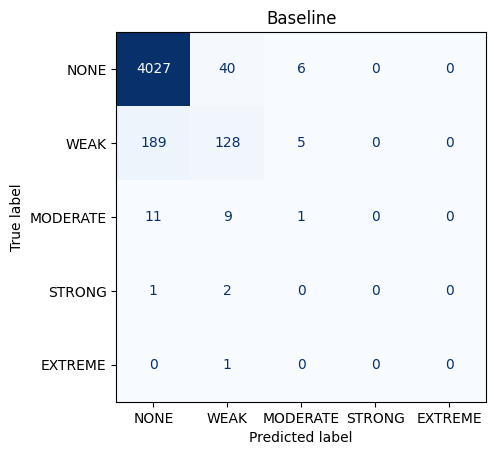

In [59]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

print("=== Multiclass Ordinal Classifier ===")
print(classification_report(y_test_mclass, y_pred))

cm = confusion_matrix(y_test_mclass, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['NONE', 'WEAK', 'MODERATE', 'STRONG', 'EXTREME'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Baseline')
plt.show()

=== Baseline Classifier ===
              precision    recall  f1-score   support

        NONE       0.95      0.99      0.97      4073
        WEAK       0.71      0.39      0.51       322
    MODERATE       0.00      0.00      0.00        21
      STRONG       1.00      0.33      0.50         3
     EXTREME       0.00      0.00      0.00         1

    accuracy                           0.94      4420
   macro avg       0.53      0.34      0.40      4420
weighted avg       0.93      0.94      0.93      4420



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


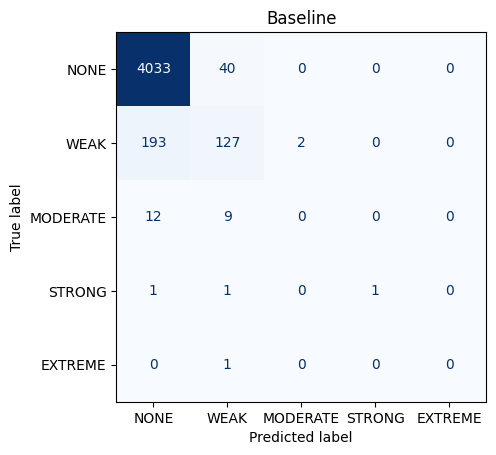

In [60]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

print("=== Baseline Classifier ===")
print(classification_report(y_test_mclass, y_pred_baseline, target_names=['NONE', 'WEAK', 'MODERATE', 'STRONG', 'EXTREME']))

cm = confusion_matrix(y_test_mclass, y_pred_baseline)
disp = ConfusionMatrixDisplay(cm, display_labels=['NONE', 'WEAK', 'MODERATE', 'STRONG', 'EXTREME'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Baseline')
plt.show()

Analisando as métricas e matrizes de confusão podemos concluir que ambos os modelos tem desempenho parecido com o classificador multiclasse ordinal sendo ligeiramente melhor que o modelo base.

A maioria dos erros acontece entre classes vizinhas (None e Weak), mas o restante das classes tem muitos poucos exemplos para serem relevantes.

# 3 SHAP Values [Cancelado]

# 4 Redução de dimensionalidade

In [61]:
import pickle
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

f = open("A652.pickle", 'rb')

(X_train, y_train, X_val, y_val, X_test, y_test) = pickle.load(f)

X_all = np.concatenate([X_train, X_val, X_test], axis=0)
y_all = np.concatenate([y_train, y_val, y_test], axis=0)

total_len = len(X_all)
idx = int(total_len * 0.8)

D1_X_train, D1_y_train = X_all[:idx], y_all[:idx]
X_test, y_test = X_all[idx:], y_all[idx:]

idx = int(total_len * 0.8)

X_train, X_val, y_train, y_val = train_test_split(
    D1_X_train, D1_y_train, test_size=0.2, random_state=42
)

def categorize(y):
  if y == 0:
    return 0
  if y <= 5:
    return 1
  if y <= 25:
    return 2
  if y <= 50:
    return 3
  if y > 50:
    return 4

y_train_mclass = np.array([categorize(y) for y in y_train])
y_val_mclass = np.array([categorize(y) for y in y_val])
y_test_mclass = np.array([categorize(y) for y in y_test])

Scaler = StandardScaler()
X_train_scaled = Scaler.fit_transform(X_train)
X_val_scaled = Scaler.transform(X_val)
X_test_scaled = Scaler.transform(X_test)

Realizando import e categorização dos dados

In [62]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score

def train_pred(X_tr, y_tr, X_val):
    models = []
    for i in range(4):
        y_bin = np.array([1 if y > i else 0 for y in y_tr])
        # SE houver apenas 1 classe (ex: tudo zero), guardamos o valor constante
        if len(np.unique(y_bin)) < 2:
            models.append(y_bin[0])  # Guarda 0 ou 1 direto
        else:
            clf = GradientBoostingClassifier()
            clf.fit(X_tr, y_bin)
            models.append(clf)

    results = []
    for i in range(4):
       # SE guardamos um valor constante, a probabilidade é o próprio valor
      if isinstance(models[i], (int, np.integer)):
        results.append(np.full(len(X_val), float(models[i])))
      else:
        results.append(models[i].predict_proba(X_val)[:, 1])

    prob = np.zeros([len(X_val), 5])
    prob[:,0] = 1 - results[0]
    prob[:,1] = results[0] - results[1]
    prob[:,2] = results[1] - results[2]
    prob[:,3] = results[2] - results[3]
    prob[:,4] = results[3]

    return np.argmax(prob, axis=1)


best_k = None
best = 0
total_features = X_train_scaled.shape[1]

for k in range(1, total_features):
  pca_temp = PCA(n_components=k)
  X_train_pca = pca_temp.fit_transform(X_train_scaled)
  X_val_pca = pca_temp.transform(X_val_scaled)

  y_val_pred = train_pred(X_train_pca, y_train_mclass, X_val_pca)
  score = f1_score(y_val_mclass, y_val_pred, average='macro')

  if score > best:
    best = score
    best_k = k

print(f"Melhor valor de k: {best_k} - com score de: {best}")

Melhor valor de k: 10 - com score de: 0.36122146290164087


Realizamos uma busca exaustiva (Grid Search) para encontrar o número ideal de componentes do PCA (k) com base no desempenho do modelo no conjunto de validação.
É testado diferentes dimensões do PCA, transforma as fatias de dados, aplica o classificador e avalia o resultado usando a métrica F1-Score

In [63]:
from sklearn.metrics import classification_report

D1_X_train_scaled = np.concatenate([X_train_scaled, X_val_scaled], axis=0)
D1_y_mclass = np.concatenate([y_train_mclass, y_val_mclass], axis=0)
y_pred_baseline = train_pred(D1_X_train_scaled, D1_y_mclass, X_test_scaled)
print(classification_report(y_test_mclass, y_pred_baseline, target_names=['NONE', 'WEAK', 'MODERATE', 'STRONG', 'EXTREME']))

              precision    recall  f1-score   support

        NONE       0.95      0.99      0.97      4073
        WEAK       0.71      0.40      0.51       322
    MODERATE       0.08      0.05      0.06        21
      STRONG       0.00      0.00      0.00         3
     EXTREME       0.00      0.00      0.00         1

    accuracy                           0.94      4420
   macro avg       0.35      0.29      0.31      4420
weighted avg       0.93      0.94      0.93      4420



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [64]:
from sklearn.metrics import classification_report

pca = PCA(n_components=best_k)
D2_train = pca.fit_transform(D1_X_train_scaled)
D2_test = pca.transform(X_test_scaled)
D2_y_mclass = D1_y_mclass

y_pred_pca = train_pred(D2_train, D2_y_mclass, D2_test)
print(classification_report(y_test_mclass, y_pred_pca, target_names=['NONE', 'WEAK', 'MODERATE', 'STRONG', 'EXTREME']))

              precision    recall  f1-score   support

        NONE       0.94      0.99      0.96      4073
        WEAK       0.63      0.21      0.31       322
    MODERATE       0.00      0.00      0.00        21
      STRONG       1.00      0.33      0.50         3
     EXTREME       0.00      0.00      0.00         1

    accuracy                           0.93      4420
   macro avg       0.51      0.31      0.36      4420
weighted avg       0.91      0.93      0.91      4420



A precisão do modelo caiu levemente na classe None ao usar o PCA e caiu consideravelmente na predição das outras classes com exceção de da Strong. Nesse caso, houve vantagem no uso do PCA, possivelmente o método causou a perda de informação relevante para predição dos dados de outras classes, mas compensou com melhora na predição de uma.

# 5 Predição Conforme

In [69]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, FunctionTransformer

diamonds = pd.read_csv("https://raw.githubusercontent.com/AILAB-CEFET-RJ/cic1205/main/data/diamonds.csv")

X_dev, X_test, y_dev, y_test = train_test_split(
    diamonds.drop(columns=['price']),
    diamonds['price'],
    test_size=0.2,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.2,
    random_state=42
)

num_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']
cat_cols = ['cut', 'color', 'clarity']

cut_order    = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order  = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order= ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

preprocessor = ColumnTransformer(transformers=[
    ('std', StandardScaler(), num_cols),
    ("ord", OrdinalEncoder(categories=[cut_order, color_order, clarity_order]), cat_cols)
])

Realizando o import dos dados, separação em treino, validação e teste e normalização das features.

In [70]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error


pipe = Pipeline([('pre', preprocessor), ('model', GradientBoostingRegressor())])
pipe.fit(X_train, y_train)
y_pred_baseline = pipe.predict(X_val)
print(f"Baseline: {mean_squared_error(y_val, y_pred_baseline):.2f}")

Baseline: 381670.40


Treinando modelo

In [71]:
import numpy as np

alpha = 0.1

pipe_low = Pipeline([('pre', preprocessor), ('model', GradientBoostingRegressor(loss='quantile', alpha=alpha/2))])
pipe_low.fit(X_train, y_train)
pipe_high = Pipeline([('pre', preprocessor), ('model', GradientBoostingRegressor(loss='quantile', alpha=1-(alpha/2)))])
pipe_high.fit(X_train, y_train)

y_pred_low = pipe_low.predict(X_val)
y_pred_high = pipe_high.predict(X_val)

Treinamento dos modelos para previsão do intervalo quantis de 90% de cobertura

In [72]:
scores = np.maximum(y_pred_low - y_val, y_val - y_pred_high)

N = len(X_val)

# Fórmula do quantil corrigido para amostras finitas
quantile_idx = (1 - alpha) * (1 + 1 / N)

q = np.quantile(scores, quantile_idx)

pred_low_test = pipe_low.predict(X_test)
pred_high_test = pipe_high.predict(X_test)

# Intervalos finais conformes
inter_low = pred_low_test - q
inter_high = pred_high_test + q

Realizamos o cálculo para realizar a correção dos intervalos para terem a cobertura desejada

In [74]:
widths = inter_high - inter_low
avg_width = np.mean(widths)

covered = (y_test >= inter_low) & (y_test <= inter_high)
cov = np.mean(covered)

print(f"Cobertura Empírica: {cov * 100:.2f}%")
print(f"Largura Média dos Intervalos: {avg_width:.2f}")

idx_mais_estreito = np.argmin(widths)
idx_mais_largo = np.argmax(widths)

print(f"Mais estreito - idx: {idx_mais_estreito}, Largura: {widths[idx_mais_estreito]}")
print(f"Mais largo - idx: {idx_mais_largo}, Largura: {widths[idx_mais_largo]}")
print("\n")
print("--- Exemplo mais estreito ---")
print(f"Preço real: {y_test.iloc[idx_mais_estreito]}")
print(f"Largura do intervalo: {widths[idx_mais_estreito]:.2f}")
print(X_test.iloc[idx_mais_estreito].to_string())

print("\n--- Exemplo mais largo ---")
print(f"Preço real: {y_test.iloc[idx_mais_largo]}")
print(f"Largura do intervalo: {widths[idx_mais_largo]:.2f}")
print(X_test.iloc[idx_mais_largo].to_string())

Cobertura Empírica: 90.14%
Largura Média dos Intervalos: 2137.49
Mais estreito - idx: 4727, Largura: 6.119413065897334
Mais largo - idx: 1930, Largura: 15265.0477809072


--- Exemplo mais estreito ---
Preço real: 998
Largura do intervalo: 6.12
carat           0.43
cut        Very Good
color              G
clarity          VS1
depth           59.3
table           58.0
x               4.97
y               5.02
z               2.96

--- Exemplo mais largo ---
Preço real: 17995
Largura do intervalo: 15265.05
carat      1.93
cut        Fair
color         F
clarity     VS1
depth      58.9
table      62.0
x          8.17
y          7.97
z          4.75


O modelo pode estar mais certo no primeiro exemplo por ter mais exemplos similares a ele, que é um diamante relativamente pequeno, algo mais comum. Enquanto o segundo exemplo que tem uma incerteza bem maior pode ser um diamante mais raro, não há muitos exemplos iguais. Ele é bem mais pesado e maior o que faz ele ser bem mais único e aumenta exponencialmente seu preço.